# Image classifier for plant leaf diseases.
Through two phases: building a CNN from scratch to understand the mechanics,

then fine-tuning a pretrained model to see what state-of-the-art transfer learning buys you.

- Data pipeline: Use tf.data with ImageDataGenerator.

    Apply augmentation (flip, rotation, zoom) and visualize effects.



---


- Phase 1 : Custom CNN: Design a 4-6 layer CNN with Conv2D → MaxPool → Dropout blocks.

    Train and plot accuracy/loss.



---



- Phase 2 : Transfer Learning: Fine-tune EfficientNetB0 or MobileNetV2.

    Freeze base layers, train head, then unfreeze and fine-tune with a low learning rate.


---


- Visualization: Plot 9 sample predictions with true/predicted labels.

    Show the confusion matrix across all classes.

---

- Analysis: Compare Phase 1 vs Phase 2 accuracy.

    How many parameters does each model have?
    
    What does dropout prevent?



# phase 1

## Data Pipeline Setup

> data loading

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [ ]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)
base_path = path
print(os.listdir(base_path))

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.
Path to dataset files: /kaggle/input/new-plant-diseases-dataset
['New Plant Diseases Dataset(Augmented)', 'new plant diseases dataset(augmented)', 'test']


In [ ]:
dataset_path = os.path.join(
    base_path,
    "New Plant Diseases Dataset(Augmented)",
    "New Plant Diseases Dataset(Augmented)"
)
print(os.listdir(dataset_path))

['valid', 'train']


In [ ]:
train_dir = os.path.join(dataset_path, 'train')
validation_dir = os.path.join(dataset_path, 'valid')
test_dir = os.path.join(base_path, "test")
print(train_dir)
print(validation_dir)
print(test_dir)

/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
/kaggle/input/new-plant-diseases-dataset/test


> Augmentation using `tf.data` with `ImageDataGenerator`.`

In [ ]:
# Define image dimensions
IMG_SIZE = (224, 224)
IMG_HEIGHT, IMG_WIDTH = IMG_SIZE

# Batch size for training
BATCH_SIZE = 32

# ImageDataGenerator & augmentation
train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=35,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# validation and testing -> only rescaling
validation_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Load images
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False #in order for evaluation
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Found 33 images belonging to 1 classes.


> Visualize Augmented Images


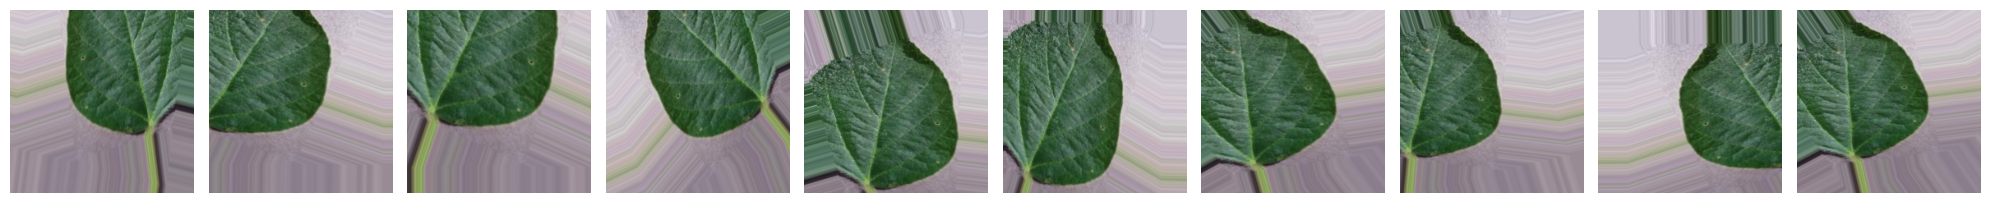

In [ ]:
def plot_images(images_arr):
    fig, axes = plt.subplots(1, 10, figsize=(20, 20))
    axes = axes.flatten()

    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# see random -_-
sample_images, _ = next(train_generator)
img = sample_images[0]
augmented_images = [train_datagen.random_transform(img) for _ in range(10)]
plot_images(augmented_images)

## Custom CNN Model Definition
> Conv -> Pooling -> droput > dense -> Output

In [ ]:
#number of classes from the train_generator
num_classes = train_generator.num_classes
print(f"Number of classes: {num_classes}")

Number of classes: 38


In [ ]:
# Build CNN
model = models.Sequential([
    # 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT,IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    # 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # 4
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Feature Mapping
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    #Output
    layers.Dense(num_classes, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,698,022 (37.00 MB)

 Trainable params: 9,698,022 (37.00 MB)

 Non-trainable params: 0 (0.00 B)

> Compile & Optimization


In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Train the Custom CNN Model

> callbacks `time is money`

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [ ]:
steps_per_epoch = 800
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce, checkpoint],
    steps_per_epoch=steps_per_epoch,
    verbose=1
)

Epoch 1/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.1789 - loss: 2.9159
Epoch 1: val_accuracy improved from None to 0.50489, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 534s 668ms/step - accuracy: 0.2682 - loss: 2.5215 - val_accuracy: 0.5049 - val_loss: 1.6431 - learning_rate: 0.0010
Epoch 2/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 513ms/step - accuracy: 0.4907 - loss: 1.6558
Epoch 2: val_accuracy improved from 0.50489 to 0.69190, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 451s 564ms/step - accuracy: 0.5372 - loss: 1.4961 - val_accuracy: 0.6919 - val_loss: 0.9833 - learning_rate: 0.0010
Epoch 3/15
597/800 ━━━━━━━━━━━━━━━━━━━━ 1:38 486ms/step - accuracy: 0.6455 - loss: 1.1303

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 3: val_accuracy improved from 0.69190 to 0.76298, saving model to best_model.h5


...


Epoch 7: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 402s 502ms/step - accuracy: 0.8014 - loss: 0.6325 - val_accuracy: 0.8625 - val_loss: 0.4193 - learning_rate: 0.0010
Epoch 8/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.8228 - loss: 0.5495
Epoch 8: val_accuracy did not improve from 0.86245
800/800 ━━━━━━━━━━━━━━━━━━━━ 397s 497ms/step - accuracy: 0.8205 - loss: 0.5592 - val_accuracy: 0.8428 - val_loss: 0.4918 - learning_rate: 0.0010
Epoch 9/15
597/800 ━━━━━━━━━━━━━━━━━━━━ 1:30 443ms/step - accuracy: 0.8332 - loss: 0.5273
Epoch 9: val_accuracy improved from 0.86245 to 0.88954, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 298s 373ms/step - accuracy: 0.8332 - loss: 0.5311 - val_accuracy: 0.8895 - val_loss: 0.3434 - learning_rate: 0.0010
Epoch 10/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8373 - loss: 0.5068
Epoch 10: val_accuracy improved from 0.88954 to 0.89745, saving model to best_model.h5



Epoch 10: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 390s 487ms/step - accuracy: 0.8415 - loss: 0.4943 - val_accuracy: 0.8975 - val_loss: 0.3168 - learning_rate: 0.0010
Epoch 11/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.8506 - loss: 0.4651
Epoch 11: val_accuracy improved from 0.89745 to 0.91566, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 391s 489ms/step - accuracy: 0.8530 - loss: 0.4601 - val_accuracy: 0.9157 - val_loss: 0.2602 - learning_rate: 0.0010
Epoch 12/15
597/800 ━━━━━━━━━━━━━━━━━━━━ 1:31 451ms/step - accuracy: 0.8566 - loss: 0.4707
Epoch 12: val_accuracy did not improve from 0.91566
800/800 ━━━━━━━━━━━━━━━━━━━━ 304s 380ms/step - accuracy: 0.8609 - loss: 0.4490 - val_accuracy: 0.9081 - val_loss: 0.2806 - learning_rate: 0.0010
Epoch 13/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.8680 - loss: 0.4185
Epoch 13: val_accuracy did not improve from 0.91566
800/800 ━━━━━━━━━━━━━━━━━━━━ 400s 500ms/step - accuracy: 0.8661 - loss: 0.4184 - val_accuracy: 0.8486 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 14/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8722 - loss: 0.3982
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: val_accuracy did not improve from 0.91566
800/800 ━━━━


Epoch 15: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 297s 371ms/step - accuracy: 0.9046 - loss: 0.2946 - val_accuracy: 0.9374 - val_loss: 0.1938 - learning_rate: 5.0000e-04


>> كفايه كده

> Plot Training and Validation Curves


In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

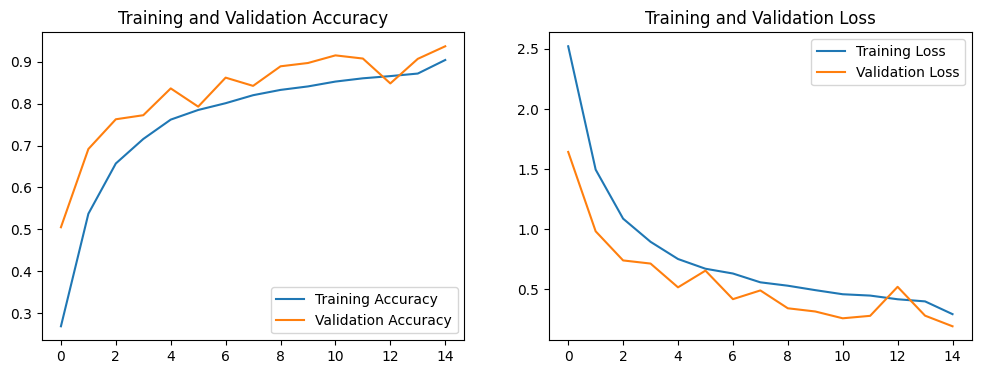

In [ ]:
plt.figure(figsize=(12, 4))
# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

## Evaluate Model


In [ ]:
print(train_generator.image_shape)
print(test_generator.image_shape)

(224, 224, 3)
(224, 224, 3)


In [ ]:
predictions = model.predict(test_generator)
predicted_labels = np.argmax(predictions, axis=1)
class_names = list(train_generator.class_indices.keys())
for i in range(len(predicted_labels)):
    print(f"Image {i} → Predicted: {class_names[predicted_labels[i]]}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step 
Image 0 → Predicted: Apple___Cedar_apple_rust
Image 1 → Predicted: Apple___Cedar_apple_rust
Image 2 → Predicted: Apple___Cedar_apple_rust
Image 3 → Predicted: Apple___Cedar_apple_rust
Image 4 → Predicted: Apple___Apple_scab
Image 5 → Predicted: Apple___Apple_scab
Image 6 → Predicted: Potato___Early_blight
Image 7 → Predicted: Corn_(maize)___Common_rust_
Image 8 → Predicted: Corn_(maize)___Common_rust_
Image 9 → Predicted: Corn_(maize)___Common_rust_
Image 10 → Predicted: Potato___Early_blight
Image 11 → Predicted: Potato___Early_blight
Image 12 → Predicted: Apple___healthy
Image 13 → Predicted: Potato___Early_blight
Image 14 → Predicted: Potato___Early_blight
Image 15 → Predicted: Potato___healthy
Image 16 → Predicted: Potato___healthy
Image 17 → Predicted: Tomato___Early_blight
Image 18 → Predicted: Tomato___Early_blight
Image 19 → Predicted: Tomato___Early_blight
Image 20 → Predicted: Tomato___Early_blight
Image 21 → Predicted: Tomato___Early_bl

In [ ]:
print("Evaluating model on validation data...")

test_loss, test_acc = model.evaluate(validation_generator)

print(f"\nValidation Loss: {test_loss:.4f}")
print(f"Validation Accuracy: {test_acc:.4f}")

Evaluating model on validation data...
550/550 ━━━━━━━━━━━━━━━━━━━━ 37s 66ms/step - accuracy: 0.9374 - loss: 0.1938

Validation Loss: 0.1938
Validation Accuracy: 0.9374


# Phase 2: MobileNetV2

In [37]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.applications.efficientnet import preprocess_input


In [38]:
IMG_SIZE = (224, 224)
num_classes = train_generator.num_classes

In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    include_top=False,
    weights='imagenet'
)
# Freeze
base_model.trainable = False

base_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Add a Custom Classification Head
frozen base model. Then train new 'head' our specific dataset.

In [31]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

In [34]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

validation_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [40]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [41]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce, checkpoint],
    steps_per_epoch=steps_per_epoch,
    verbose=1
)

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.6582 - loss: 1.1586
Epoch 1: val_accuracy improved from None to 0.86365, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 413s 516ms/step - accuracy: 0.7336 - loss: 0.8746 - val_accuracy: 0.8636 - val_loss: 0.4377 - learning_rate: 0.0010
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.8127 - loss: 0.5731
Epoch 2: val_accuracy improved from 0.86365 to 0.88835, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 376s 471ms/step - accuracy: 0.8254 - loss: 0.5411 - val_accuracy: 0.8883 - val_loss: 0.3438 - learning_rate: 0.0010
Epoch 3/10
597/800 ━━━━━━━━━━━━━━━━━━━━ 1:25 423ms/step - accuracy: 0.8448 - loss: 0.4815

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 3: val_accuracy did not improve from 0.88835
800/800 ━━━━━━━━━━━━━━━━━━━━ 287s 359ms/step - accuracy: 0.8442 - loss: 0.4778 - val_accuracy: 0.8853 - val_loss: 0.3433 - learning_rate: 0.0010
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8528 - loss: 0.4517
Epoch 4: val_accuracy improved from 0.88835 to 0.90758, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 382s 478ms/step - accuracy: 0.8534 - loss: 0.4506 - val_accuracy: 0.9076 - val_loss: 0.2891 - learning_rate: 0.0010
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.8596 - loss: 0.4298
Epoch 5: val_accuracy improved from 0.90758 to 0.91805, saving model to best_model.h5



Epoch 5: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 374s 468ms/step - accuracy: 0.8611 - loss: 0.4237 - val_accuracy: 0.9181 - val_loss: 0.2510 - learning_rate: 0.0010
Epoch 6/10
597/800 ━━━━━━━━━━━━━━━━━━━━ 1:23 412ms/step - accuracy: 0.8635 - loss: 0.4082
Epoch 6: val_accuracy did not improve from 0.91805
800/800 ━━━━━━━━━━━━━━━━━━━━ 278s 348ms/step - accuracy: 0.8665 - loss: 0.4021 - val_accuracy: 0.9048 - val_loss: 0.2904 - learning_rate: 0.0010
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - accuracy: 0.8685 - loss: 0.4032
Epoch 7: val_accuracy improved from 0.91805 to 0.92084, saving model to best_model.h5



Epoch 7: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 382s 468ms/step - accuracy: 0.8664 - loss: 0.4029 - val_accuracy: 0.9208 - val_loss: 0.2356 - learning_rate: 0.0010
Epoch 8/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8760 - loss: 0.3777
Epoch 8: val_accuracy did not improve from 0.92084
800/800 ━━━━━━━━━━━━━━━━━━━━ 377s 472ms/step - accuracy: 0.8752 - loss: 0.3792 - val_accuracy: 0.9038 - val_loss: 0.2831 - learning_rate: 0.0010
Epoch 9/10
597/800 ━━━━━━━━━━━━━━━━━━━━ 1:22 408ms/step - accuracy: 0.8780 - loss: 0.3688
Epoch 9: val_accuracy improved from 0.92084 to 0.92528, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 276s 345ms/step - accuracy: 0.8802 - loss: 0.3648 - val_accuracy: 0.9253 - val_loss: 0.2271 - learning_rate: 0.0010
Epoch 10/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8826 - loss: 0.3609
Epoch 10: val_accuracy did not improve from 0.92528
800/800 ━━━━━━━━━━━━━━━━━━━━ 371s 464ms/step - accuracy: 0.8820 - loss: 0.3605 - val_accuracy: 0.9224 - val_loss: 0.2343 - learning_rate: 0.0010


### Unfreeze Base Layers and Fine-tune the Entire Model


In [42]:
# 1. Unfreeze partially
base_model.trainable = True
for layer in base_model.layers[:200]:
    layer.trainable = False

# 2. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 3. Train
history_fine = model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator,
    callbacks=[early_stop, lr_reduce, checkpoint],
    steps_per_epoch=steps_per_epoch,
    verbose=1
)

Epoch 1/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.8892 - loss: 0.3340
Epoch 1: val_accuracy improved from 0.92528 to 0.92989, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 438s 535ms/step - accuracy: 0.8929 - loss: 0.3193 - val_accuracy: 0.9299 - val_loss: 0.2138 - learning_rate: 1.0000e-05
Epoch 2/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.9003 - loss: 0.3002
Epoch 2: val_accuracy improved from 0.92989 to 0.93114, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
800/800 ━━━━━━━━━━━━━━━━━━━━ 373s 467ms/step - accuracy: 0.9020 - loss: 0.2990 - val_accuracy: 0.9311 - val_loss: 0.2110 - learning_rate: 1.0000e-05
Epoch 3/5
597/800 ━━━━━━━━━━━━━━━━━━━━ 1:24 414ms/step - accuracy: 0.9061 - loss: 0.2786

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 3: val_accuracy did not improve from 0.93114
800/800 ━━━━━━━━━━━━━━━━━━━━ 282s 353ms/step - accuracy: 0.9068 - loss: 0.2828 - val_accuracy: 0.9309 - val_loss: 0.2099 - learning_rate: 1.0000e-05
Epoch 4/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9050 - loss: 0.2941
Epoch 4: val_accuracy did not improve from 0.93114
800/800 ━━━━━━━━━━━━━━━━━━━━ 371s 464ms/step - accuracy: 0.9063 - loss: 0.2890 - val_accuracy: 0.9310 - val_loss: 0.2081 - learning_rate: 1.0000e-05
Epoch 5/5
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.9058 - loss: 0.2838
Epoch 5: val_accuracy did not improve from 0.93114
800/800 ━━━━━━━━━━━━━━━━━━━━ 371s 465ms/step - accuracy: 0.9062 - loss: 0.2820 - val_accuracy: 0.9305 - val_loss: 0.2082 - learning_rate: 1.0000e-05


> Plot Training and Validation Curves for Fine-tuning


In [43]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Extend with data from FINE-TUNING
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']
loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

# Setup Plotting
initial_epochs = len(history.history['accuracy'])

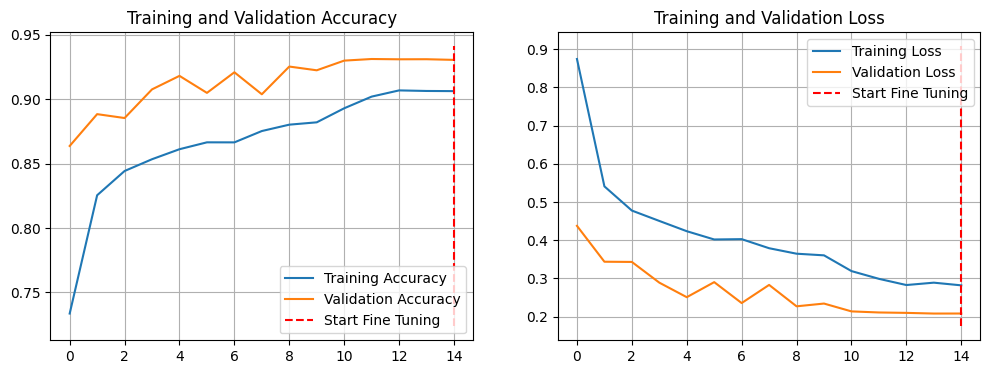

In [44]:
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
# Mark the point where fine-tuning started
plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning', linestyle='--', color='red')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
# Mark the point where fine-tuning started
plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning', linestyle='--', color='red')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)

plt.show()

> Evaluate Fine-tuned

In [47]:
print("Evaluating model on validation data...")

val_loss, val_acc = model.evaluate(validation_generator)

print(f"\nValidation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

Evaluating model on validation data...
550/550 ━━━━━━━━━━━━━━━━━━━━ 40s 73ms/step - accuracy: 0.9310 - loss: 0.2081

Validation Loss: 0.2081
Validation Accuracy: 0.9310


### Visualize Sample Predictions

Let's visualize 9 sample images from the test set with their true and predicted labels from the fine-tuned MobileNetV2 model.

In [48]:
# batch of images and labels
sample_test_images, sample_test_labels = next(validation_generator)

# predictions
sample_predictions = model.predict(sample_test_images)
predicted_classes = np.argmax(sample_predictions, axis=1)
true_classes = np.argmax(sample_test_labels, axis=1)

# class names
class_names_list = list(validation_generator.class_indices.keys())

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


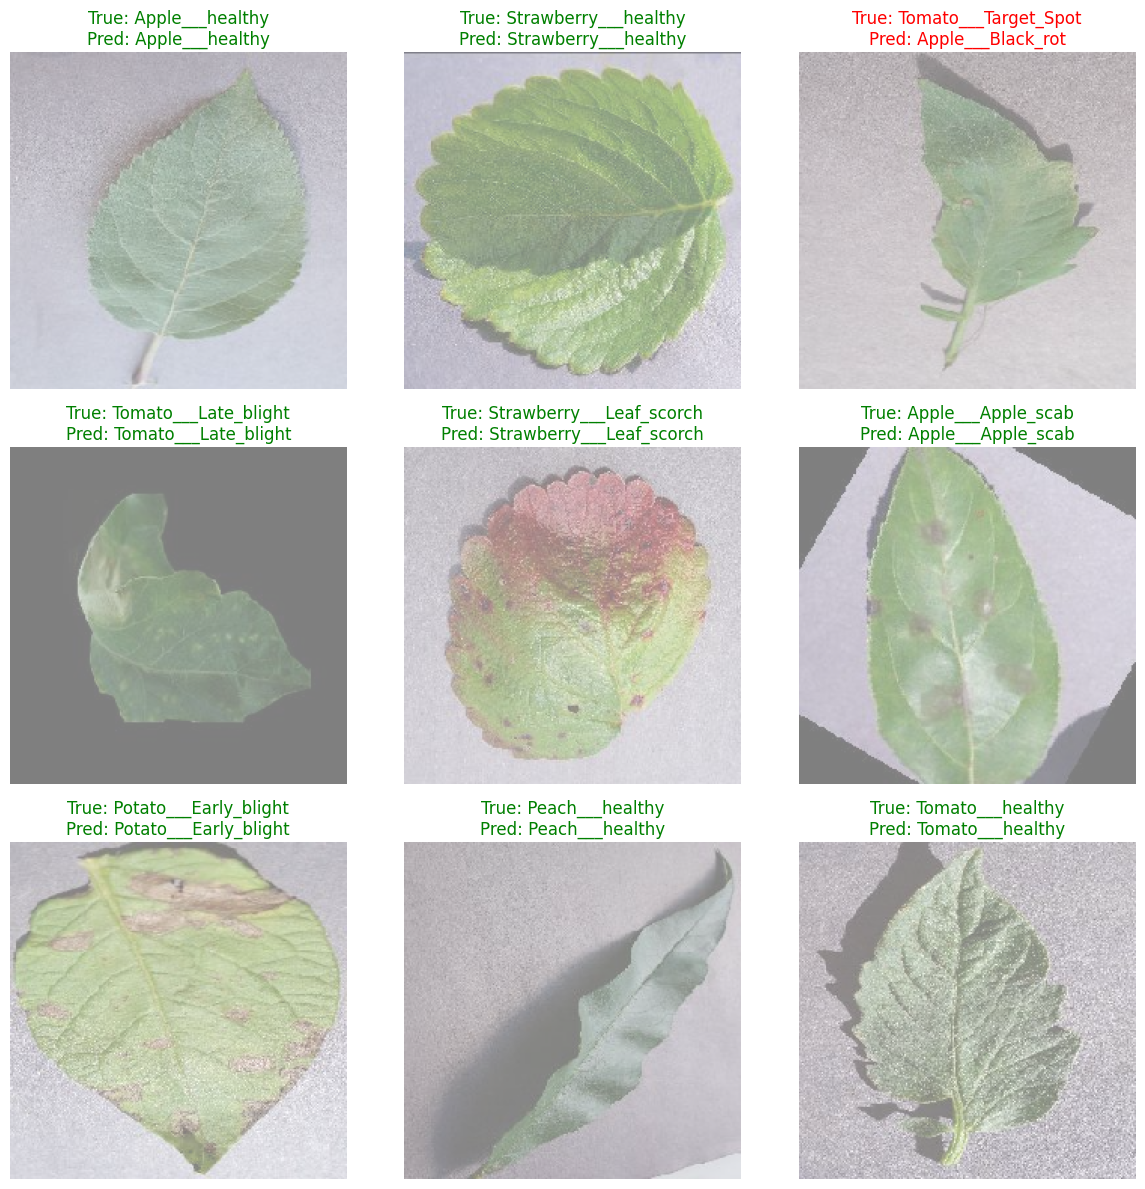

In [49]:
# Plotting
num_samples_to_plot = 9
plt.figure(figsize=(12, 12))

for i in range(num_samples_to_plot):
    ax = plt.subplot(3, 3, i + 1)
    img = sample_test_images[i]
    img = (img + 1) / 2

    plt.imshow(img)

    # Label logic
    true_label = class_names_list[true_classes[i]]
    predicted_label = class_names_list[predicted_classes[i]]

    color = "green" if predicted_label == true_label else "red"
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

### What does Dropout Prevent?

**Dropout** is a regularization technique used in neural networks to prevent overfitting. During training, it randomly sets a fraction of the neurons' outputs to zero at each update. This means that at each training step, a different 'thinned' network is being trained.

**How it prevents overfitting:**
1.  **Reduces co-adaptation:** By randomly dropping out neurons, the network cannot rely on any single neuron or specific set of neurons. This forces neurons to learn more robust features that are useful in conjunction with many different random subsets of other neurons.
2.  **Ensembles of models:** Dropout can be seen as training an ensemble of many different neural networks, where each network is formed by a subset of the neurons. Since each network is trained on different subsets of features, they are less likely to overfit to the training data.
3.  **Encourages independent feature learning:** It prevents complex co-dependencies on training data, where a slight change in the input features would significantly impact the prediction. Instead, each neuron is encouraged to learn a useful feature on its own, making the model more robust.

In essence, dropout makes the model less sensitive to the specific weights of individual neurons, leading to better generalization on unseen data.